In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


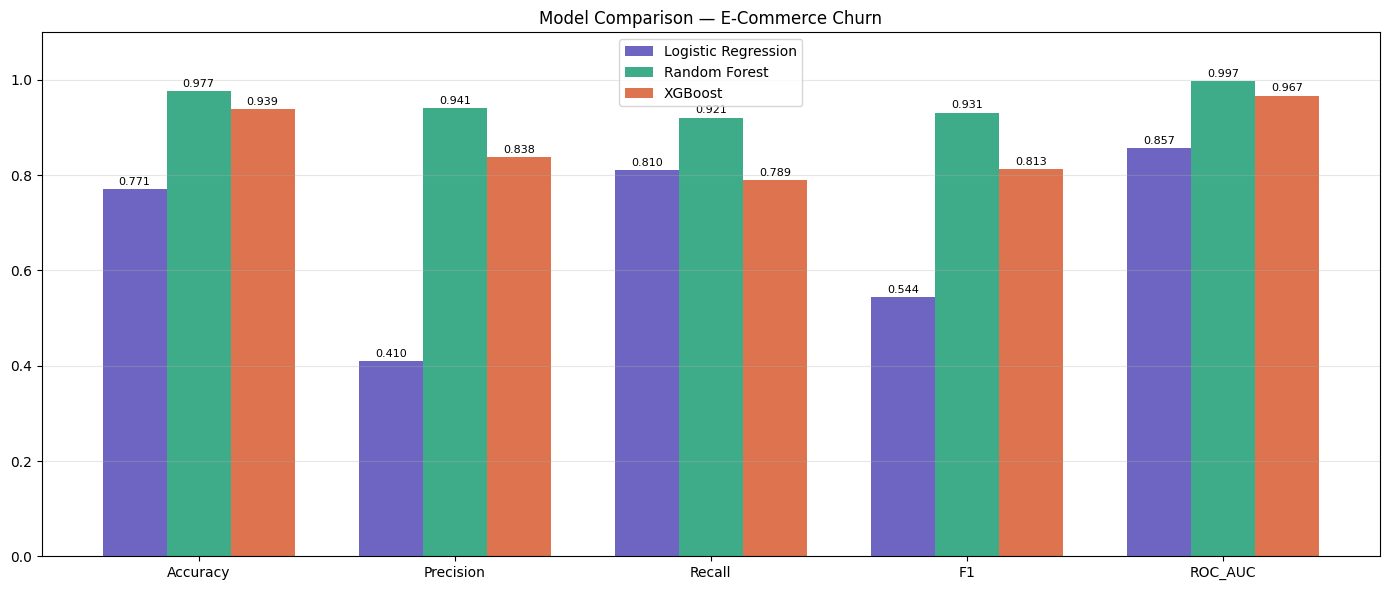

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.read_csv('outputs/results/all_results.csv')
ecom_results = results[results['Sector']=='E-Commerce'].copy()

metrics = ['Accuracy','Precision','Recall','F1','ROC_AUC']
models  = ecom_results['Model'].tolist()
colors  = ['#534AB7','#1D9E75','#D85A30']

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = ecom_results[
        ecom_results['Model']==model
    ][metrics].values[0]
    bars = ax.bar(x + i*width, vals, width,
                  label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8
        )

ax.set_title('Model Comparison — E-Commerce Churn')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/10_model_comparison.png',
            bbox_inches='tight')
plt.show()

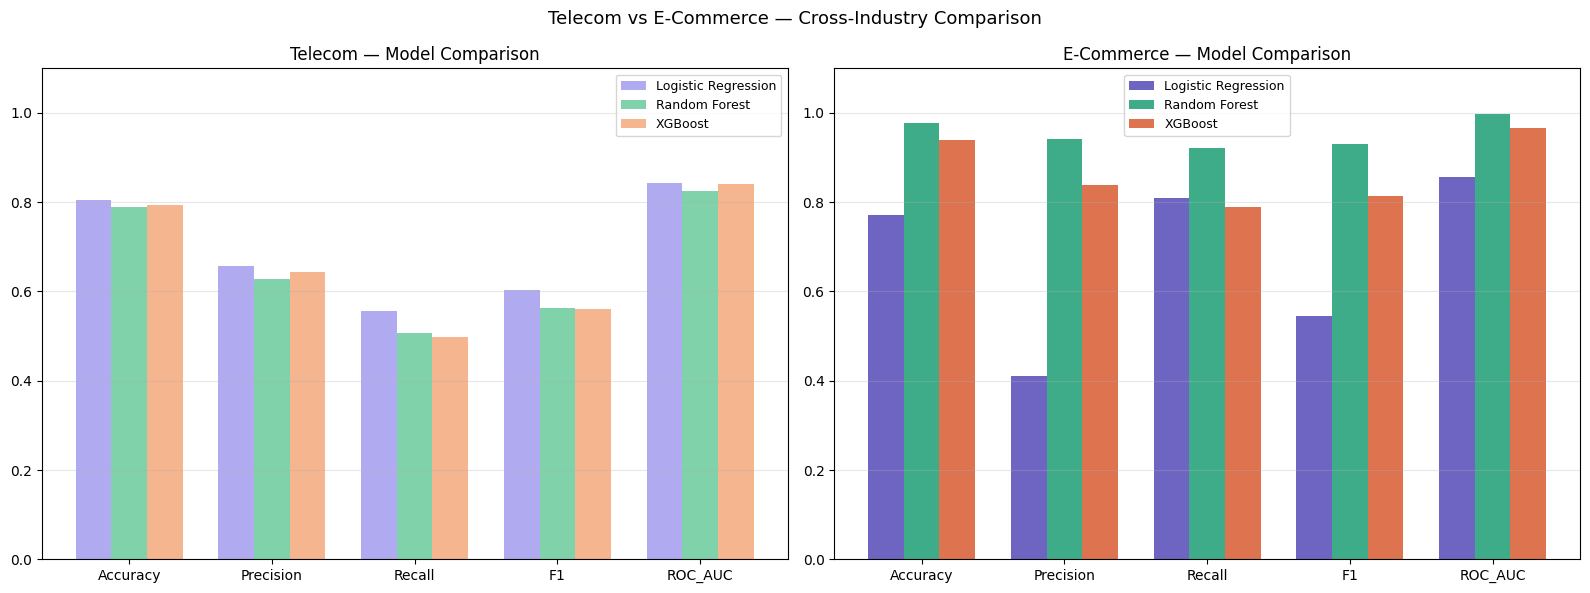

In [3]:
results = pd.read_csv('outputs/results/all_results.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sector, color_set in [
    (axes[0], 'Telecom',    ['#A39CEE','#6ACA9C','#F4A87A']),
    (axes[1], 'E-Commerce', ['#534AB7','#1D9E75','#D85A30']),
]:
    s_df = results[results['Sector']==sector]
    x = np.arange(len(metrics))
    for i, (_, row) in enumerate(s_df.iterrows()):
        ax.bar(x + i*0.25, row[metrics].values,
               0.25, label=row['Model'],
               color=color_set[i], alpha=0.85)
    ax.set_title(f'{sector} — Model Comparison')
    ax.set_xticks(x + 0.25)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Telecom vs E-Commerce — Cross-Industry Comparison',
             fontsize=13)
plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/11_cross_sector_comparison.png',
            bbox_inches='tight')
plt.show()